# **Metode Euler**

Metode Euler adalah salah satu metode paling sederhana untuk ODE.

Mulai dari:

$$ \frac{dy}{dt} = f(t,y) $$

Gunakan pendekatan turunan maju:

$$ \frac{dy}{dt} \approx \frac{y_{n+1} - y_n}{\Delta t} $$

Sehingga:

$$ \frac{y_{n+1} - y_n}{\Delta t} = f(t_n, y_n) $$

maka:

$$ \boxed{y_{n+1} = y_n + \Delta t f(t_n, y_n)} $$

jadi

$$ \boxed{\text{nilai baru = nilai sekarang + perubahan}} $$

Dengan kata lain:

$$ y_{\text{baru}} = y_{\text{sekarang}} + \text{laju perubahan} \times \Delta t $$

**Peluruhan Eksponensial**

Misalkan:

$$ \frac{dN}{dt} = - \lambda N $$

dengan $N_0 = 100$ dan $\lambda = 0.1$, maka:

$$ f(t,N) = -0.1N $$

Metode Euler:

$$ N_{n+1} = N_n + \Delta t(-0.1N_n) $$

atau:

$$ \boxed{N_{n+1} = N_n(1-0.1\Delta t)} $$

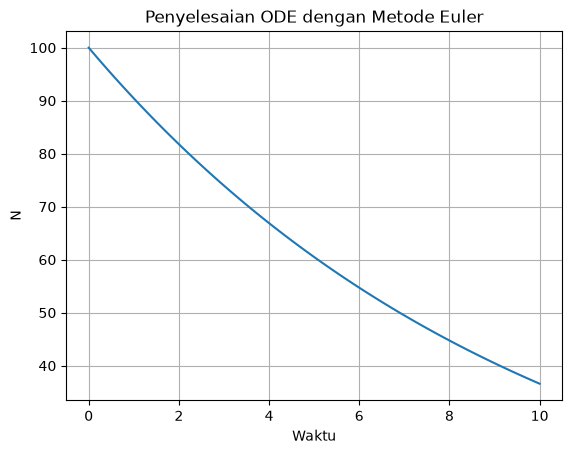

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
N0 = 100
lam = 0.1

dt = 0.1
t_akhir = 10

# Array waktu
t = np.arange(0, t_akhir + dt, dt)

# Array solusi
N = np.zeros(len(t))

# Kondisi awal
N[0] = N0

# Metode Euler
for i in range(len(t) - 1):
    dNdt = -lam * N[i]
    N[i + 1] = N[i] + dt * dNdt

# Plot
plt.plot(t,N)
plt.xlabel("Waktu")
plt.ylabel("N")
plt.title("Penyelesaian ODE dengan Metode Euler")
plt.grid()
plt.show()

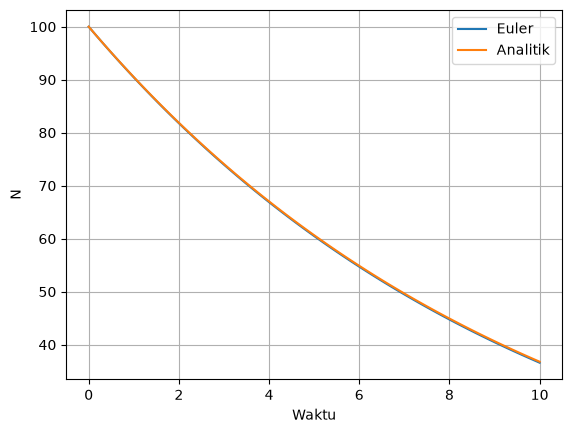

In [2]:
N_analitik = N0 * np.exp(-lam * t)

plt.plot(t, N, label="Euler")
plt.plot(t, N_analitik, label="Analitik")
plt.xlabel("Waktu")
plt.ylabel("N")
plt.legend()
plt.grid()
plt.show()

# **Euler-Cromer**

Dalam fisika, metode Euler biasa terkadang memberikan perilaku yang buruk untuk sistem seperti osilator.

Misalnya:

$$ \frac{dx}{dt} = v $$

dan:

$$ \frac{dv}{dt} = a $$

Euler biasa:

$$ x_{n+1} = x_n + v_n \Delta t $$

$$ v_{n+1} = v_n + a_n \Delta t $$

Euler-Cormer menggunakan kecepatan **yang sudah diperbarui**:

$$ \boxed{v_{n+1} = v_n + a_n \Delta t} $$

Kemudian:

$$ \boxed{x_{n+1} = x_n + v_{n+1} \Delta t} $$

Perubahan kecil ini sangat penting untuk beberapa simulasi fisika.

**Osilator Harmonik**

Persamaan:

$$ m \frac{d^2x}{dt^2} = -kx $$

$$ \frac{d^2x}{dt^2} = -\frac{k}{m}x $$

$$ \frac{dv}{dt} = -\frac{k}{m}x $$

Sekarang masalah orde kedua berubah menjadi **dua ODE orde pertama**.

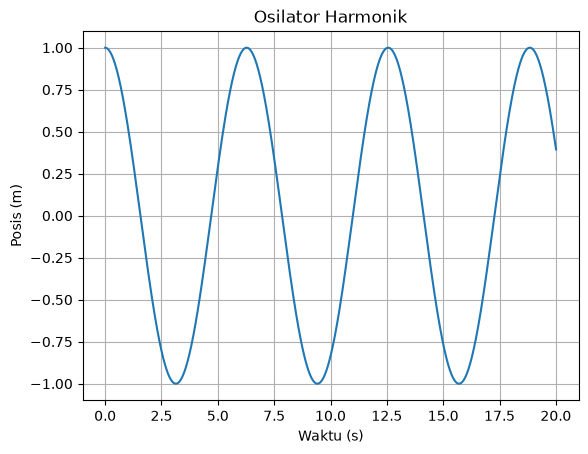

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
m = 1.0
k = 1.0

x0 = 1.0
v0 = 0.0

dt = 0.01
t_akhir = 20

t = np.arange(0, t_akhir + dt, dt)

x = np.zeros(len(t))
v = np.zeros(len(t))

x[0] = x0
v[0] = v0

# Euler-Cromer
for i in range(len(t) - 1):
    a = -(k / m) * x[i]
    v[i + 1] = v[i] + a * dt
    x[i + 1] = x[i] + v[i + 1] * dt

plt.plot(t,x)
plt.xlabel("Waktu (s)")
plt.ylabel("Posis (m)")
plt.title("Osilator Harmonik")
plt.grid()
plt.show()

# **Runge-Kutta Orde 2**

Euler hanya menggunakan informasi dari satu titik:

$$ f(t_n, y_n) $$

Runge-Kutta menggunakan beberapa evaluasi fungsi untuk memperoleh estimasi yang lebik baik.

Salah satu bentuk RK2:

$$ k_1 = f(t_n, y_n) $$

$$ k_2 = f(t_n + \Delta t, y_n + k_1 \Delta t) $$

Kemudian:

$$ \boxed{y_{n+1} = y_n + \frac{\Delta t}{2} (k_1 + k_2)} $$

RK2 memiliki global error:

$$ O(\Delta t^2) $$

sehingga secara umum lebih akurat daripada Euler.

# **Runge-Kutta Orde 4**

Definisikan:

$$k_1 = f(t_n, y_n)$$

$$k_2 = f\left(t_n + \frac{\Delta t}{2}, y_n + \frac{k_1 \Delta t}{2}\right)$$

$$k_3 = f\left(t_n + \frac{\Delta t}{2}, y_n + \frac{k_2 \Delta t}{2}\right)$$

$$k_4 = f(t_n + \Delta t, y_n + k_3 \Delta t)$$

Kemudian:

$$\boxed{y_{n+1} = y_n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)}$$

RK4 mempunyai global error:

$$\boxed{O(\Delta t^4)}$$

Ini menjadikannya jauh lebih akurat daripada Euler untuk banyak masalah non-stiff.

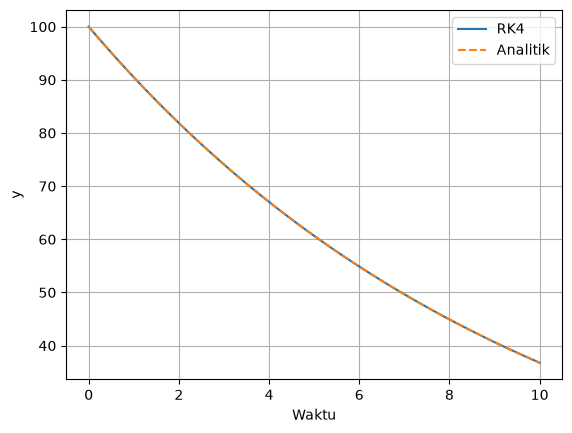

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -0.1 * y

def rk4(f, t, y0):
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t) - 1):
        dt = t[i + 1] - t[i]

        k1 = f(t[i], y[i])

        k2 = f(t[i] + dt / 2, y[i] + k1 * dt / 2)

        k3 = f(t[i] + dt / 2, y[i] + k2 * dt / 2)

        k4 = f(t[i] + dt, y[i] + k3 * dt)

        y[i + 1] = y[i] + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return y

# Parameter
y0 = 100
dt = 0.1

t = np.arange(0, 10 + dt, dt)

# RK4
y = rk4(f, t, y0)

# Solusi analitik
y_exact = y0 * np.exp(-0.1 * t)

plt.plot(t, y, label="RK4")
plt.plot(t, y_exact, "--", label="Analitik")

plt.xlabel("Waktu")
plt.ylabel("y")

plt.legend()
plt.grid()
plt.show()

# **Menggunakan SciPy**

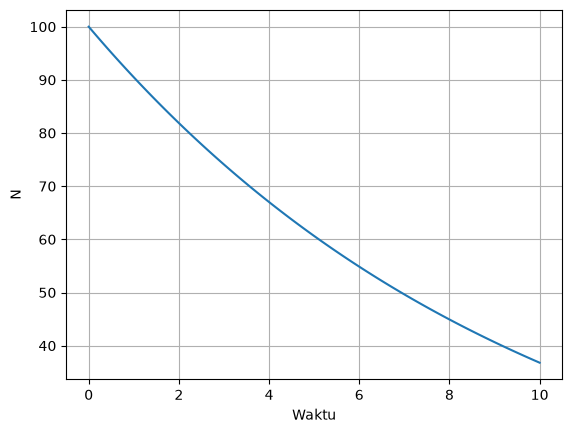

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f(t, y):
    return -0.1 * y

sol = solve_ivp(
    f,
    [0, 10],
    [100],
    t_eval=np.linspace(0, 10, 100)
)

plt.plot(sol.t, sol.y[0])

plt.xlabel("Waktu")
plt.ylabel("N")

plt.grid()
plt.show()

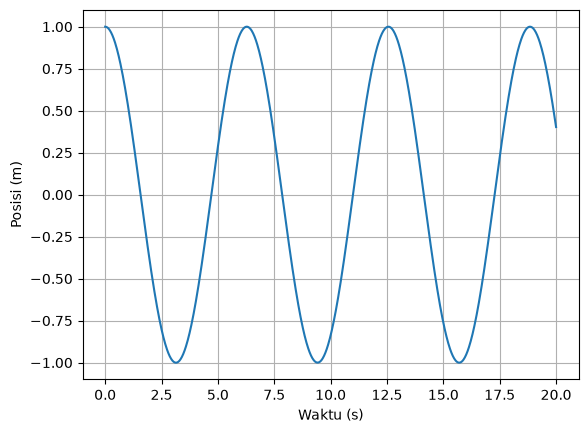

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

m = 1.0
k = 1.0

def osilator(t, y):

    x = y[0]
    v = y[1]

    dxdt = v
    dvdt = -(k / m) * x

    return [dxdt, dvdt]


t_span = [0, 20]

y0 = [1.0, 0.0]

t_eval = np.linspace(0, 20, 1000)

sol = solve_ivp(
    osilator,
    t_span,
    y0,
    t_eval=t_eval
)

x = sol.y[0]
v = sol.y[1]

plt.plot(sol.t, x)

plt.xlabel("Waktu (s)")
plt.ylabel("Posisi (m)")

plt.grid()
plt.show()